# Uncertainties in modelling and Monte Carlo methods.
### Load libraries

We're going to use the well known routines we used for creating phase planes.


In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Latex
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import seaborn as sns
import pandas as pd
import sympy as sp
import matplotlib.gridspec as gridspec

%matplotlib inline
def plot_flow(ax,rhs,xrange=[-2.5,2.5],yrange=[-2.5,2.5],xnum=100,ynum=100,nullclines=False,args=None):
    # Set up u,v space
    u = np.linspace(xrange[0], xrange[1], xnum)
    v = np.linspace(yrange[0], yrange[1], ynum)
    uu, vv = np.meshgrid(u, v)

# Compute derivatives
    u_vel = np.empty_like(uu)
    v_vel = np.empty_like(vv)
    for i in range(uu.shape[0]):
        for j in range(uu.shape[1]):
            u_vel[i,j], v_vel[i,j] = rhs(0,np.array([uu[i,j], vv[i,j]]),*args)


# Make stream plot
    ax.streamplot(uu, vv, u_vel, v_vel,color='grey')
#Nullclines
    if nullclines:
        ax.contour(uu, vv, u_vel, [0],colors=('r'))
        ax.contour(uu, vv, v_vel, [0],colors=('b'))

    return ax

# A function that plots a path
# def plot_solution(ax,rhs,y0,t_end,t_dim=2000,color='green',init_pt=True,linewidth=2.5):

#     t = np.linspace(0, t_end, t_dim)
#     X = sc.integrate.solve_ivp(rhs,t_span=[t[0],t[-1]],y0=y0,t_eval=t)
#     x,y=X.y
#     t=X.t
#     ax.plot(x,y, color=color,linewidth=linewidth)
#     if (init_pt):
#         ax=plot_point(ax,y0,color=color)
#     return ax

def get_solution(rhs, y0, t_end, t_dim=2000,args=None):
    t = np.linspace(0, t_end, t_dim)
    sol = sc.integrate.solve_ivp(rhs, t_span=[t[0], t[-1]], y0=y0, t_eval=t,args=args)
    return sol

def plot_solution(ax, rhs, y0, t_end, t_dim=2000, color='green', init_pt=True, linewidth=2.5, linestyle='-',args=None):
    sol = get_solution(rhs, y0, t_end, t_dim,args)
    x, y = sol.y
    ax.plot(x, y, color=color, linewidth=linewidth,linestyle=linestyle)
    if init_pt:
        ax = plot_point(ax, y0, color=color)
    return ax

def plot_point(ax, coord, color='black',markersize=20):
    """Add fixed points to plot."""
    x,y=coord
    ax.plot(x,y, '.', color='black', markerfacecolor=color, markersize=markersize)
    return ax


def jacobian(rhs, xy, eps=1e-8,args=None):
    """
    Compute the Jacobian matrix of a system of differential equations at a given point.
    Parameters:
    rhs (function): The right-hand side function of the differential equations. It should take two arguments: time (t) and state (xy).
    xy (array-like): The point (x, y) at which to evaluate the Jacobian.
    eps (float, optional): A small perturbation value for numerical differentiation. Default is 1e-8.
    Returns:
    numpy.ndarray: A 2x2 Jacobian matrix evaluated at the point (x, y).
    Note:
    This function uses finite differences to approximate the partial derivatives.

    WARNING: The code and comment are from Gemini, use at own risk.
    """


    f0 = np.array(rhs(0, xy,args))
    jac = np.zeros((2, 2))

    for i in range(2):
        dxy = np.zeros(2)
        dxy[i] = eps
        f1 = np.array(rhs(0, xy + dxy,args))
        jac[:, i] = (f1 - f0) / eps

    return jac

def eigenvalues_eigenvectors(jac):
    """
    Calculate the eigenvalues and eigenvectors of a given Jacobian matrix.
    Parameters:
    jac (numpy.ndarray): A square matrix representing the Jacobian matrix.
    Returns:
    tuple: A tuple containing two elements:
        - eigenvalues (numpy.ndarray): An array of eigenvalues.
        - eigenvectors (numpy.ndarray): An array of eigenvectors, where each column is an eigenvector corresponding to the eigenvalue at the same index.


    WARNING: The code and comment are from Gemini, use at own risk.
    """

    eigenvalues, eigenvectors = np.linalg.eig(jac)
    return eigenvalues, eigenvectors





def plot_jordan(ax,rhs,r0=[0,0],rr=1,num=25,vectors=True, color='blue',linewidth=1.5,linestyle='dashed',args=None):
    theta=np.linspace(0,2*np.pi, num)
    x=rr*np.cos(theta)+r0[0]
    y=rr*np.sin(theta)+r0[1]
    ax.plot(x,y,linewidth=linewidth, color=color)
    if vectors:
        U,V=rhs(0,[x,y],args)
        ax.quiver(x,y,U,V)

    return ax




def winding_number(rhs, r0, rr, num=1000,args=None):
    theta = np.linspace(0, 2 * np.pi, num)
    x = rr * np.cos(theta) + r0[0]
    y = rr * np.sin(theta) + r0[1]

    F,G=rhs(0,[x,y],args)
    angles = np.arctan2(G, F)
    integrated_angle = np.sum(np.diff(np.unwrap(angles)))

    return integrated_angle / (2 * np.pi)




## The damped pendulum

We will use the pendulum as the example problem.

Remember that the non-linear damped pendulum is described by
$$
\begin{array}{rcl}
\dot{x} &=& \ y \\
\dot{y} &=& - \omega^2 \sin (x) - \varphi  y
\end{array}
$$
where $\omega=\sqrt{g/l}$ is the frequency and  $\varphi=b/m$ is a friction parameter.



## Phase diagrams and analysis

### The phase diagram.

In [2]:
# Define the system of ODEs,
def rhs_pendulum(t, xy, omega, phi ):
    x,y=xy
    dx = y
    dy = - omega**2 * np.sin(x) - phi*y
    return [dx, dy]


<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_994/210972441.py:18: SyntaxWarning: invalid escape sequence '\p'
  ax.title.set_text(f'Phase portrait of the pendulum with damping, $\phi$={phi}')


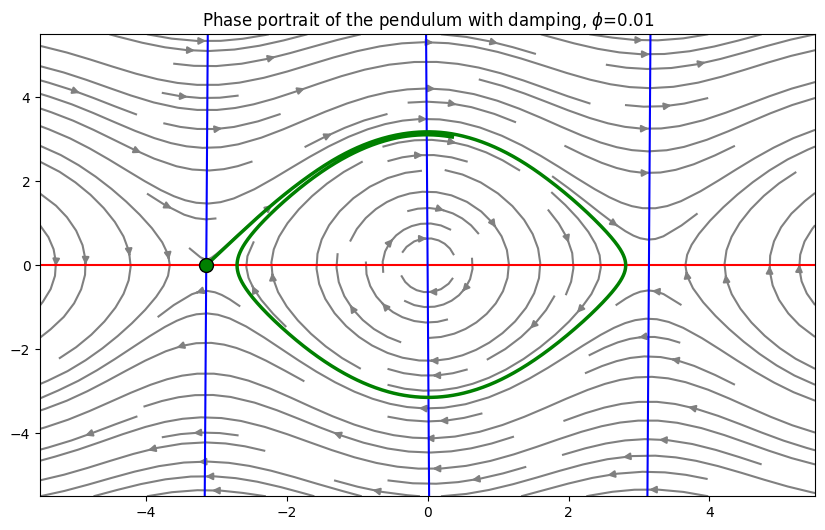

In [30]:

phi = 0.01 # Change this to a positive value to introduce damping

L= 1.5
omega = np.sqrt(9.81/L)

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
xrange=[-5.5, 5.5]
yrange=[-5.5, 5.5]
# Plot the flow
plot_flow(ax, rhs_pendulum, xrange=xrange,yrange=yrange, args=(omega, phi),nullclines=True)

# Plot the equilibrium points

# Plot the eigenvectors at the equilibrium points
initial_condition = [-np.pi,0.01]
plot_solution(ax, rhs_pendulum, initial_condition, t_end=10*np.pi/omega, color='green', args=(omega, phi))#,linestyle='dotted')
ax.title.set_text(f'Phase portrait of the pendulum with damping, $\phi$={phi}')

# Show the plot
ax.set_xlim(xrange)
ax.set_ylim(yrange)
plt.show()


<font color='green'> Play with the damping factor, </font> $\phi$, <font color='green'>what do you see?</font>
Damping is taking the energy out of the system. duh.

## Solutions in the time domain.
Demonstrating numerical damping / energy drift / phase drift.



<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_994/677553472.py:36: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f'Pendulum angle over time no damping and $\Delta t=$ {t_data[1]-t_data[0]:.3f} ')


CPU time:  0.062731 seconds
Wall time: 0.117109 seconds


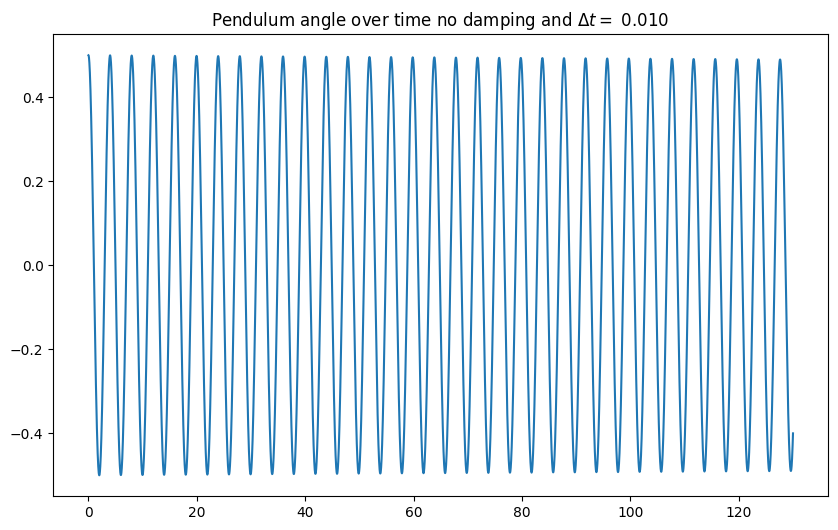

In [32]:
import time

phi = 0. #damping

L= 1.5
omega = np.sqrt(9.81/L)

t_max=130 # Maximum time

t_num=t_max*100 # Number of time points
rtol=1e-3,  # Relative tolerance for the ODE solver
atol=1e-6  # Absolute tolerance for the ODE solver

y0=[0.5,0] # Initial condition

# Create a time array (to show the solution in time)
t_data = np.linspace(0, t_max, t_num)


start_cpu = time.process_time()
start_wall = time.perf_counter()

tmp0=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y0,t_eval=t_data,args=[omega,phi],method='RK45', rtol=rtol, atol=atol)


end_cpu = time.process_time()
end_wall = time.perf_counter()


print(f"CPU time:  {end_cpu - start_cpu:.6f} seconds")
print(f"Wall time: {end_wall - start_wall:.6f} seconds")


fig, ax = plt.subplots(1,1,figsize=(10, 6))
ax.plot(t_data, tmp0.y[0], label='y0')
ax.set_title(f'Pendulum angle over time no damping and $\Delta t=$ {t_data[1]-t_data[0]:.3f} ')
plt.show()

Do you see anything disturbing in the figure?

**Try the following**

1. Increase the _t_max_ to 1300, What do you see?
2. Change: _rtol=1e-7, atol=1e-12_ and plot again.

Can you explain what's happening?


#### Tolerances: `rtol` and `atol`

When using `scipy.integrate.solve_ivp`, the solver controls the accuracy of the numerical solution through two tolerance parameters:

- **`rtol` (relative tolerance)**: Controls the relative error of the solution. The solver aims to keep the local error below `rtol * |y|`. Default is `1e-3`.
- **`atol` (absolute tolerance)**: Controls the absolute error of the solution. Useful when the solution passes through or near zero. Default is `1e-6`.

The combined error condition the solver tries to satisfy at each step is:
$$
|e_i| \leq \texttt{atol} + \texttt{rtol} \times |y_i|
$$

**Tighter tolerances** (smaller values) lead to more accurate solutions but require more function evaluations and longer computation times.

| Parameter | Default | Tight |
|-----------|---------|-------|
| `rtol` | `1e-3` | `1e-7` |
| `atol` | `1e-6` | `1e-12` |

> For long-time integrations of conservative systems like the undamped pendulum, even tight tolerances cannot fully prevent **energy drift** — this is a fundamental limitation of non-symplectic solvers.
#### Symplectic Solvers

Standard ODE solvers (like RK45) do not conserve the **energy** of Hamiltonian systems such as the pendulum. Over long integration times, this leads to **energy drift** — the amplitude slowly grows or decays even without friction.

**Symplectic integrators** are specifically designed to preserve the geometric structure of Hamiltonian systems. Key properties:

- They conserve a **modified Hamiltonian** close to the true one, bounding energy error over long times
- They preserve **phase space volume** (Liouville's theorem)
- Common examples: **Störmer-Verlet**, **leapfrog**, **symplectic Euler**

The simple **symplectic Euler** update for the pendulum reads:
$$
y_{n+1} = y_n - \Delta t \, \omega^2 \sin(x_n)
$$
$$
x_{n+1} = x_n + \Delta t \, y_{n+1}
$$

Note that $y$ is updated **first**, and then used to update $x$ — this small change makes the method symplectic.

> Scipy's `solve_ivp` does **not** include symplectic solvers. Dedicated libraries such as `Julia`'s `DifferentialEquations.jl` or `Python`'s `jitcode` offer symplectic methods.

## Sensitivity to initial conditions.
Let's plot two solutions, starting close to each other, with time along the x-axis.

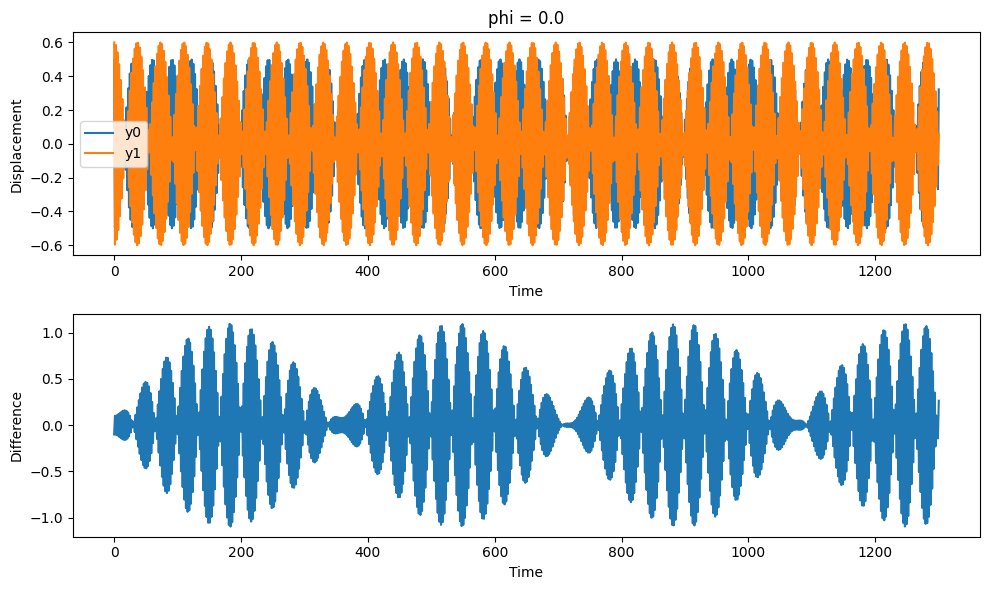

In [5]:

# Play with these values to see how the plots below change.


eps=0.1 # Perturbation in initial conditions. staring close by

L= 1.5
omega = np.sqrt(9.81/L)
phi = 0. #

rtol=1e-7,
atol=1e-12

t_max=1300 # Maximum time
t_num=1000 # Number of time points
y0=[0.5,0] # Initial condition

# Create a time array
t_data = np.linspace(0, t_max, t_num)

y1=y0+np.array([eps,0]) # Perturb the initial condition

fig, axs = plt.subplots(2,1,figsize=(10, 6))

tmp0=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y0,t_eval=t_data,args=[omega,phi],method='RK45', rtol=rtol, atol=atol)
ax=axs[0]
ax.plot(t_data, tmp0.y[0], label='y0')
tmp1=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y1,t_eval=t_data,args=[omega,phi],method='RK45', rtol=rtol, atol=atol)
ax.plot(t_data, tmp1.y[0], label='y1')

ax.set_xlabel('Time')
ax.set_ylabel('Displacement')
ax.legend()
ax.set_title(f'phi = {phi}')

ax=axs[1]
ax.plot(t_data, (tmp0.y[0]-tmp1.y[0]), label='y0-y1')
ax.set_xlabel('Time')
ax.set_ylabel('Difference')

plt.tight_layout()
plt.show()


<font color='green'> Play with the parameters in the cell above and see how the solutions and the difference changes.
  </font>



## Uncertainties in length or initial conditions
In this section, we explore how uncertainties in different parameters affect the behavior of the pendulum system. Specifically, we investigate:

- **Uncertainty in length**: How variations in the pendulum length $L$ propagate through the solution
- **Uncertainty in initial conditions**: How small perturbations in the starting position or velocity affect the trajectory over time

By comparing solutions with slightly different parameter values, we can observe the sensitivity of the dynamical system and understand how errors accumulate. This is particularly important for chaotic systems where small differences can lead to dramatically different outcomes.

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_994/2029104731.py:23: SyntaxWarning: invalid escape sequence '\p'
  ax[0].plot(tmp2.t, tmp2.y[0], label='y0=$\pi$/2+0.01')
/tmp/ipykernel_994/2029104731.py:29: SyntaxWarning: invalid escape sequence '\p'
  ax[1].plot(tmp1.t, tmp.y[0]-tmp2.y[0], label='y0=$\pi$/2+0.01')


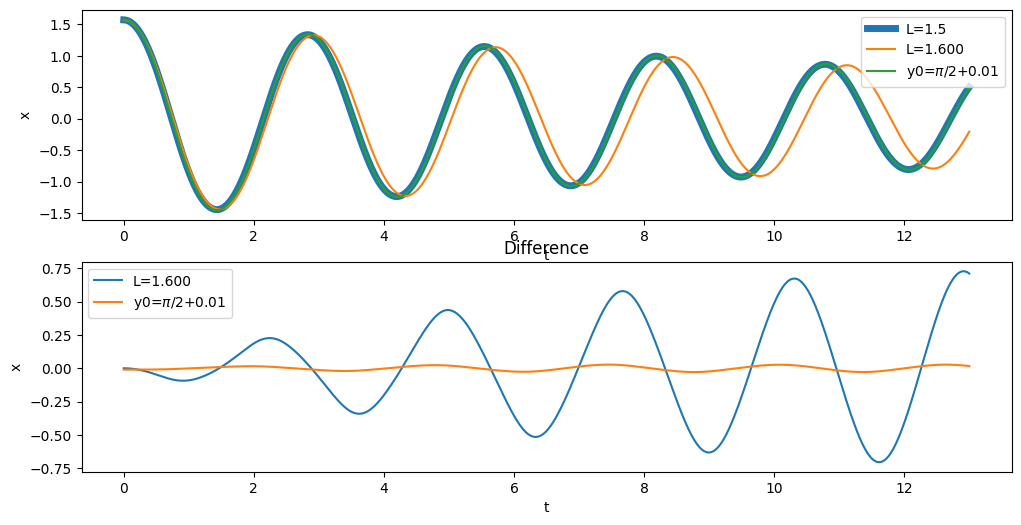

In [6]:
L= 1.5
L_perturb=0.1

omega= np.sqrt(9.81/L)

L1=L+L_perturb
omega1= np.sqrt(9.81/L1)
phi = 0.1 #
t_max=13
t_num=10000
t_data = np.linspace(0, t_max, t_num)
y0=[np.pi/2,0]
y1=[np.pi/2+0.01,0.]

tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y0,t_eval=t_data,args=[omega,phi])
tmp1=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y0,t_eval=t_data,args=[omega1,phi])
tmp2=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_data[-1]),y0=y1,t_eval=t_data,args=[omega,phi])
data=tmp.y[0] #

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(tmp.t, tmp.y[0], label=f'L={L}',linewidth=5)
ax[0].plot(tmp1.t, tmp1.y[0], label=f'L={L1:.3f}')
ax[0].plot(tmp2.t, tmp2.y[0], label='y0=$\pi$/2+0.01')
ax[0].set_xlabel('t')
ax[0].set_ylabel('x')
ax[0].legend()

ax[1].plot(tmp.t, tmp.y[0]-tmp1.y[0], label=f'L={L1:.3f}')
ax[1].plot(tmp1.t, tmp.y[0]-tmp2.y[0], label='y0=$\pi$/2+0.01')
ax[1].set_title('Difference')
ax[1].set_xlabel('t')
ax[1].set_ylabel('x')
ax[1].legend()
plt.show()

1. Change the time of integration. What do you see?
2. Introduce damping.

# Probability distributions in Python

There are many distributions and Python has many statistical libraries that can provide sampling from them. We will use the ones provided by scipy, see documentation on [https://docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)



### The uniform distribution


Mean value:  0.4830135745004852 Standard deviation:  0.2932774198060216


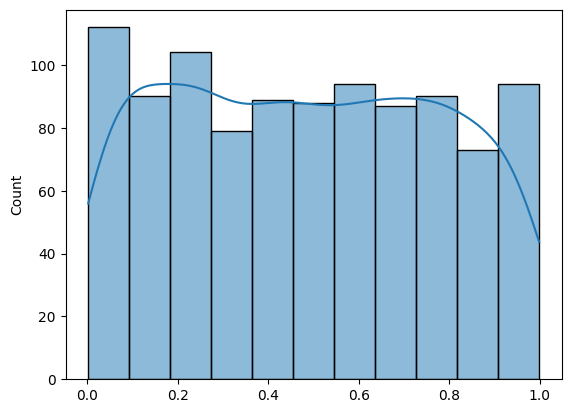

In [7]:
n = 1000 # Number of random samples to generate
start = 0 # Starting point of the uniform distribution
width = 1 # Width of the uniform distribution
x_uniform = sc.stats.uniform.rvs(size=n, loc = start, scale=width) # Generate random numbers
sns.histplot(x_uniform, kde=True) # Plot the histogram
print('Mean value: ',x_uniform.mean(),'Standard deviation: ',x_uniform.std())

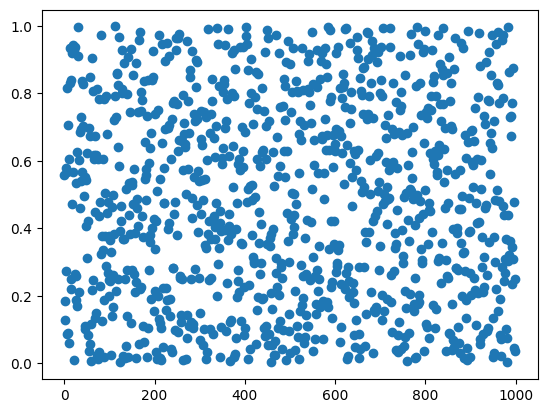

In [8]:
plt.plot(x_uniform,'o')

### The normal distribution

$$
 p(x)= \displaystyle\frac{1}{2\pi\sigma}e^{-\frac{(x-\mu)^2}{\sigma^2}}
$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

In [9]:
n=10000
loc=2
scale = 4
x_norm=sc.stats.norm.rvs(size=n,loc=loc,scale=scale)
print('Mean: ', x_norm.mean(), ' Standard deviation: ', x_norm.std())

Mean:  2.0228517365613454  Standard deviation:  4.04995048371767


<Axes: ylabel='Count'>

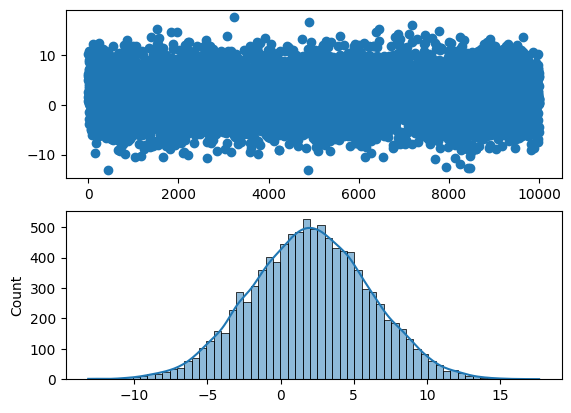

In [10]:
plt.subplot(2,1,1)
plt.plot(x_norm,'o')
plt.subplot(2,1,2)
sns.histplot(x_norm, kde=True)

There are many other probability distributions. Check [https://docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

# The pendulum (revisited)

Lets see how uncertainties in parameters influence on the model predictions.

## Parameter estimation

Let's say we're measuring a pendulum. How do we determine the friction parameter?

Do the following:
1. Create synthetic data and add noise.
2. Define an objective function
3. Use scipy.optimize.minimum to estimate the parameters.

<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_994/2313871601.py:25: SyntaxWarning: invalid escape sequence '\D'
  axs[0].set_title(f'Pendulum angle over time no damping and $\Delta t=$ {data_t[1]-data_t[0]:.3f} ')


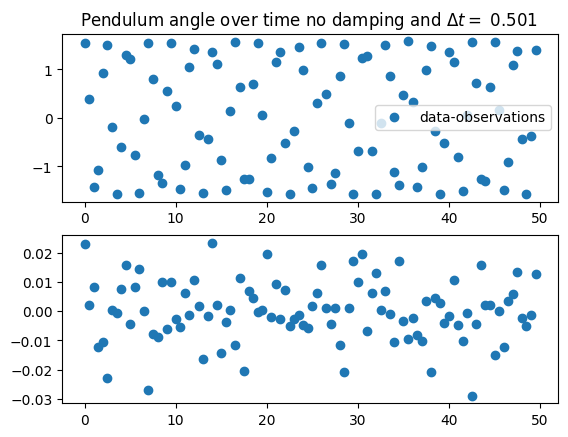

In [11]:
L= 1.
omega= np.sqrt(9.81/L)
phi = 0 #
rtol=1e-7,
atol=1e-12
t_num=1000 # Change this to a smaller value to see the effect of fewer data points
t = np.linspace(0, 50, t_num)
y0=[np.pi/2,0]

tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t[-1]),y0=y0,t_eval=t,args=[omega,phi],rtol=rtol, atol=atol)

# Add random noise to the data
num_points=10 # Change this to a smaller value to see the effect of fewer data points
data=tmp.y[0][::num_points] # Change this to real_data[::] to use all data points, or real_data[::20] to use fewer data points
data_t=tmp.t[::num_points] # Corresponding time points for the data

noise_level = 0.01 # Change this to a larger value to see the effect of more noise
observations = data * np.random.normal(1, noise_level, size=data.shape)


fig, axs = plt.subplots(2, 1)

#axs[0].plot(tmp.t,tmp.y[0],'-',label='the pendulum')
axs[0].plot(data_t,observations,'o',label='data-observations')
axs[0].set_title(f'Pendulum angle over time no damping and $\Delta t=$ {data_t[1]-data_t[0]:.3f} ')
axs[0].legend()
axs[1].plot(data_t,data-observations,'o');


Play with the noice.

So now we have a set of observations, with noise. Let's estimate the parameters based on this.

First we need an objective function.


### The objective function

In [12]:

def objective(params,t,y):
    omega, phi= params
    t_end=t[-1]
    y0=[y[0],0]
    tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_end),y0=y0,t_eval=t,args=[omega,phi],rtol=1e-7, atol=1e-12)

    return np.sum((y - tmp.y[0]) ** 2)/len(y)



In [13]:
# Lets check the objective function
omega_guess=omega
phi_guess=phi
obj_tmp=objective([omega_guess,phi_guess],data_t,observations)
obj_tmp

np.float64(0.19006292589614587)

Lets call the scipy function minimize.

In [14]:
# Ensure t_data and observations have the same length

omega_guess=1
phi_guess=phi
result = sc.optimize.minimize(objective, [omega_guess, phi_guess], args=(data_t, observations))

# Calculate the error estimates
omega_error = np.sqrt(result.hess_inv[0, 0])
phi_error = np.sqrt(result.hess_inv[1, 1])


omega_calc = result.x[0]
phi_calc = result.x[1]
print('Omega given:', omega)
print('Omega estimated:', omega_calc)
print('Omega error estimate:', omega_error)
print('Phi given:', phi)
print('Phi estimated:', phi_calc)

print('Phi error estimate:', phi_error)

Omega given: 3.132091952673165
Omega estimated: 2.7937749970231924
Omega error estimate: 0.21963070864777895
Phi given: 0
Phi estimated: 0.10864206014330194
Phi error estimate: 0.2512193154128605



1. Try to increase the noise, how good are the estimates?
2. Increase the number of observations, will the estimates be better?
3. Can you make the length of the pendulum as the unknown parameter?


<font color='green'> Can you plot the solutions with the given and estimated parameters? </font>

## Parameter uncertainties

In [15]:

# Define the system of ODEs
def rhs_pendulum(t, xy, omega,phi=0 ):
    x,y=xy
    dx = y
    dy = - omega * np.sin(x) - phi*y
    return [dx, dy]


Lets assume that we have an uncertainty in our parameters.

In [16]:
# Set parameters
length_mean = 1.5
length_std = 0.1
g=9.18


#Draw and calculate frequency
l_num=100

l_norm=np.random.normal(loc=length_mean,scale=length_std, size=l_num)
l_unif=np.random.uniform(length_mean-2*length_std,length_mean+2*length_std,l_num)
omega_norm=np.sqrt(g/l_norm)
omega_unif=np.sqrt(g/l_unif)

#Create the time vector
t_end=40.
t_num=410
t = np.linspace(0, t_end, t_num)
rtol=1e-7,
atol=1e-12
# Set initial conditions
y0=[1,0]
x_norm=np.zeros((l_num,t_num))
y_norm=np.zeros((l_num,t_num))

x_unif=np.zeros((l_num,t_num))
y_unif=np.zeros((l_num,t_num))

for ii in np.arange(len(omega_norm)):
    tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_end),y0=y0,t_eval=t,args=[omega_norm[ii],phi],rtol=rtol, atol=atol)
    x_norm[ii,:]=tmp.y[0]
    y_norm[ii,:]=tmp.y[1]

for ii in np.arange(len(omega_unif)):
    tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_end),y0=y0,t_eval=t,args=[omega_unif[ii],phi],rtol=rtol, atol=atol)
    x_unif[ii,:]=tmp.y[0]
    y_unif[ii,:]=tmp.y[1]







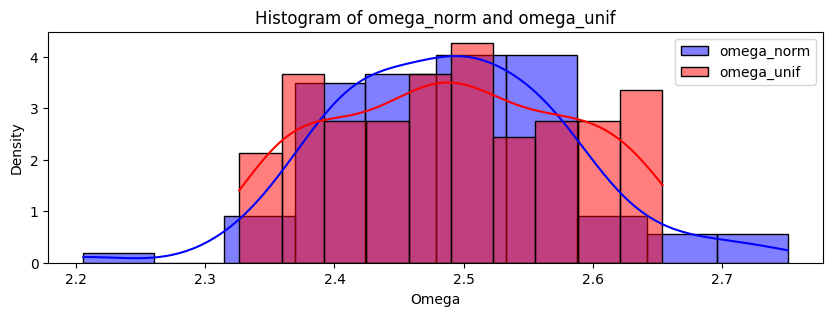

In [17]:
plt.figure(figsize=(10, 3))

# Plot histogram for omega_norm
sns.histplot(omega_norm, kde=True, color='blue', label='omega_norm', stat='density', bins=10)

# Plot histogram for omega_unif
sns.histplot(omega_unif, kde=True, color='red', label='omega_unif', stat='density', bins=10)

plt.xlabel('Omega')
plt.ylabel('Density')
plt.legend()
plt.title('Histogram of omega_norm and omega_unif')
plt.show()

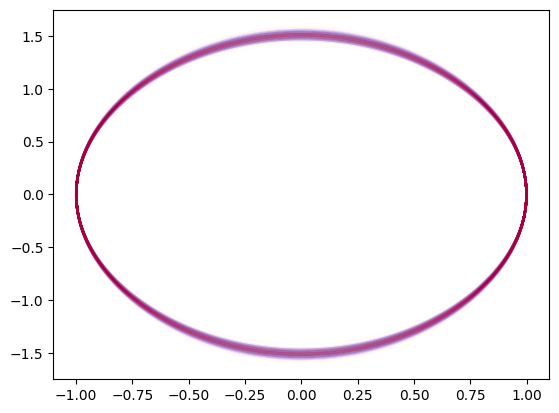

In [18]:
plt.plot(x_unif.T,y_unif.T,color='blue',alpha=0.01)
plt.plot(x_norm.T,y_norm.T,color='red',alpha=0.01)
plt.show()

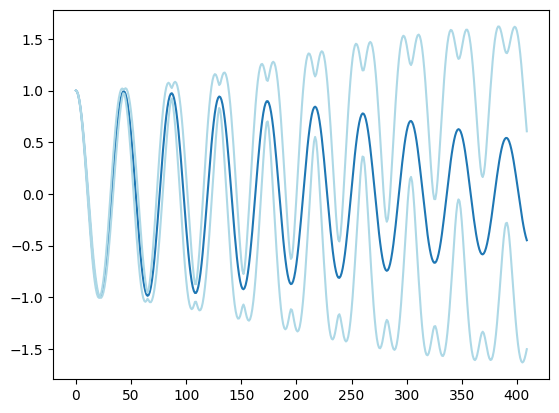

In [19]:
x=x_unif
plt.plot(x.mean(axis=0))
plt.plot(x.mean(axis=0)+2*x.std(axis=0),color='lightblue')
plt.plot(x.mean(axis=0)-2*x.std(axis=0),color='lightblue')
plt.show()

1. Can you make a loop that see how the mean and standard deviation estimate changes with the number of samples.
2. See how this changes when you increase the uncertainties.
3. Can you involve the friction term?

Here is a go at no 1.

Create first a function that run the ensemble.

Since we are only interested in the mean value and the standard deviation, $\sigma$, and to save memory we're using the following.
$$
\begin{array}{rl}
 \sigma^2 =& \frac{1}{n}\sum_i ({\overline{x}-x_i})^2=  \frac{1}{n}\sum_i (\overline{x}^2-2\overline{x} x_i + x_i^2)\\
 & \\
= & \frac{1}{n}\sum_i \overline{x}^2-2\overline{x}\frac{1}{n}\sum_i x_i + \frac{1}{n}\sum_ix_i^2\\
& \\
= & \overline{x_i^2}-\overline{x}^2
\end{array}
$$



In [20]:

def run_ensemble(l_num=1000,length_mean = 1.0, length_std = 0.1, t_end=40., y0=[1,0],t_num=410, g=9.18,dist=0):
# A function that runs the ensembles for the pendulum
# Input: l_num, the number of samples in the ensemble
#       length_mean, the mean length of the pendulum
#       length_std, standard deviation of the length of the pendulum
#       g, is the gravitational constant
#       dist, the distribution function to use
# Output: t time when we do the statistics.
#         x_mean, the mean values
#         Standard deviations.
    if (dist == 0):
        l=np.random.normal(loc=length_mean,scale=length_std, size=l_num)
    elif(dist == 1):
        l=np.random.uniform(length_mean-2*length_std,length_mean+2*length_std,l_num)
    else:
        print('Not implemented yet, distr:', dist)


    omega=np.sqrt(g/l)


#Create the time vector, this should be an input.

    t = np.linspace(0, t_end, t_num)



# Store the results.
    x=t*0
    x2=t*0


# Here we loop through the samples.

    for ii in np.arange(len(omega)):
        tmp=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_end),y0=y0,t_eval=t,args=[omega[ii],phi],rtol=1e-7, atol=1e-12)
        #Sum the x and the x squared.
        x=x+tmp.y[0]
        x2=x2+tmp.y[0]**2

# and do the statistics
    x=x/l_num
    x2=np.sqrt((x2/l_num)-x**2)
    return [t,x,x2]


In [21]:
# Create an array of samples to run
l_nums=np.array([10,50,100,200, 300, 400, 500,800,1000,1500,2000,3000, 3500, 4000, 4500, 5000])
l_nums=np.array([2,5,10,50,100,150,500])
# Create arrays.
t_num=400
# Set initial conditions, could also be an input.
y0=[1,0]

x_mean=np.zeros((len(l_nums),t_num))
x_std=np.zeros((len(l_nums),t_num))

# Calculate a solution with the mean length
length_mean = 1.0
length_std = 0.2

g=9.81
t_end=15
t = np.linspace(0, t_end, t_num)
omega=np.sqrt(g/length_mean)
sol=sc.integrate.solve_ivp(rhs_pendulum,t_span=(0.,t_end),y0=y0,t_eval=t,args=(omega,phi))

for jj in np.arange(len(l_nums)):
    tmp_t,tmp_mean,tmp_std=run_ensemble(l_num=l_nums[jj],length_mean = length_mean, length_std = 0.1,t_num=t_num,t_end=t_end, g=9.18,dist=1)
    x_mean[jj,:]=tmp_mean
    x_std[jj,:]=tmp_std



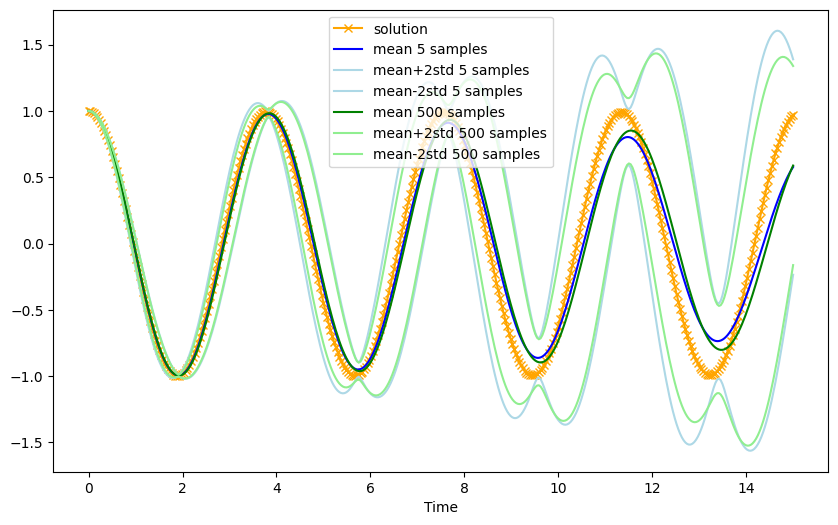

In [22]:
ii=1
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sol.t,sol.y[0],'x-',color='orange',label='solution')
ax.plot(sol.t,x_mean[ii,:],'-',color='blue',label=f'mean {l_nums[ii]} samples')
ax.plot(sol.t,x_mean[ii,:]+2*x_std[ii,:],'-',color='lightblue',label=f'mean+2std {l_nums[ii]} samples')
ax.plot(sol.t,x_mean[ii,:]-2*x_std[ii,:],'-',color='lightblue',label=f'mean-2std {l_nums[ii]} samples')

ii=-1
ax.plot(sol.t,x_mean[ii,:],'-',color='green',label=f'mean {l_nums[ii]} samples')
ax.plot(sol.t,x_mean[ii,:]+2*x_std[ii,:],'-',color='lightgreen',label=f'mean+2std {l_nums[ii]} samples')
ax.plot(sol.t,x_mean[ii,:]-2*x_std[ii,:],'-',color='lightgreen',label=f'mean-2std {l_nums[ii]} samples')

ax.legend()
ax.set_xlabel('Time');

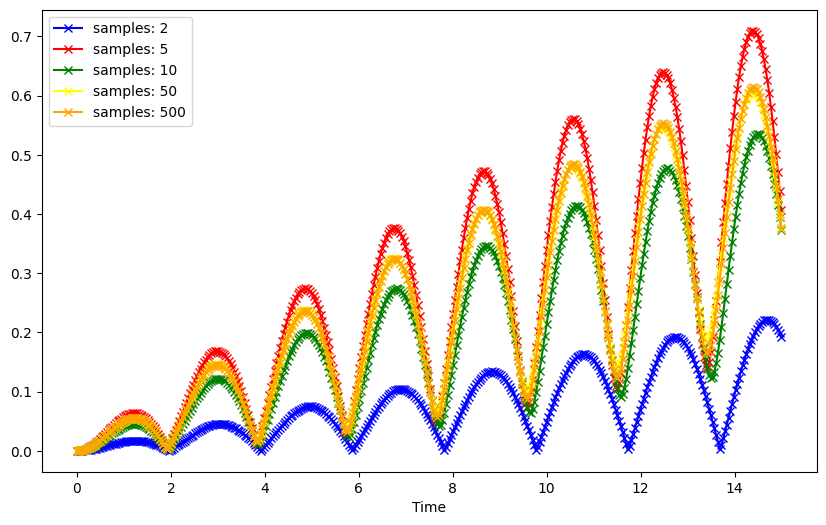

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sol.t,x_std[0,:],'x-',color='blue', label=f'samples: {l_nums[0]}')

ax.plot(sol.t,x_std[1,:],'x-',color='red', label=f'samples: {l_nums[1]}')
ax.plot(sol.t,x_std[2,:],'x-',color='green', label=f'samples: {l_nums[2]}')
ax.plot(sol.t,x_std[3,:],'x-',color='yellow',  label=f'samples: {l_nums[3]}')
ax.plot(sol.t,x_std[-1,:],'x-',color='orange', label=f'samples: {l_nums[-1]}')
ax.legend()
ax.set_xlabel('Time');

## Libraries to look into:
- Pandas [https://pandas.pydata.org/docs/index.html](https://pandas.pydata.org/docs/index.html)
- Seaborn [https://seaborn.pydata.org](https://seaborn.pydata.org)
